In [146]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100


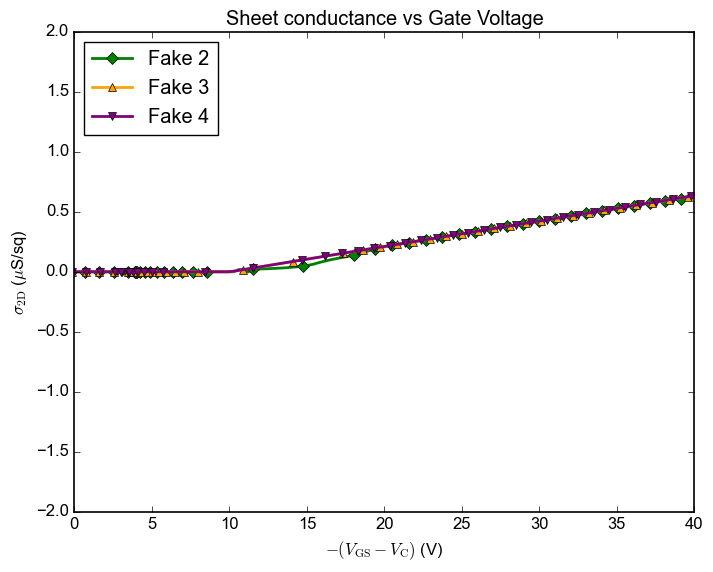

In [147]:

data1 = np.loadtxt("./Data-Mobility/20262304005.dat")
data2 = np.loadtxt("./Data-Mobility/20262304006.dat")
data3 = np.loadtxt("./Data-Mobility/20262304007.dat")
data4 = np.loadtxt("./Data-Mobility/20262304008.dat")
data_fake_1 = np.loadtxt("./Data-Mobility/20262304005_smooth_fake.dat")
data_fake_2 = np.loadtxt("./Data-Mobility/20262304006_smooth_fake.dat")
data_fake_3 = np.loadtxt("./Data-Mobility/20262304007_smooth_fake.dat")
data_fake_4 = np.loadtxt("./Data-Mobility/20262304008_smooth_fake.dat")

datasets_IDS_VDS = [
    # ("-50 nA", data1, 'cyan', 'h'),
    # ("-40 nA", data2, 'magenta', 'P'),
    # ("-30 nA", data3, 'black', 'X'),
    # ("-10 nA", data4, 'red', 'o'),
    # ("Fake 1", data_fake_1, 'blue', 's'),
    ("Fake 2", data_fake_2, 'green', 'D'),
    ("Fake 3", data_fake_3, 'orange', '^'),
    ("Fake 4", data_fake_4, 'purple', 'v'),
]
for label, data, color, marker in datasets_IDS_VDS:
    V_GS = data[:, 0]
    I_DS = data[:, 2]
    V_DS = data[:, 3]
    V_C = 0.5*(data[:, 4] + data[:, 5])
    V_12 = data[:, 6]
    sigma = data[:, 7]
    plt.plot(-(V_GS - V_C), sigma*1e6, lw=2, label=label, color=color, marker=marker, linestyle='-', markevery=10)




plt.xlabel(r"$-(V_\text{GS} - V_\text{C})$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)")
plt.xlim(0, 40)
plt.ylim(-2, 2)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()

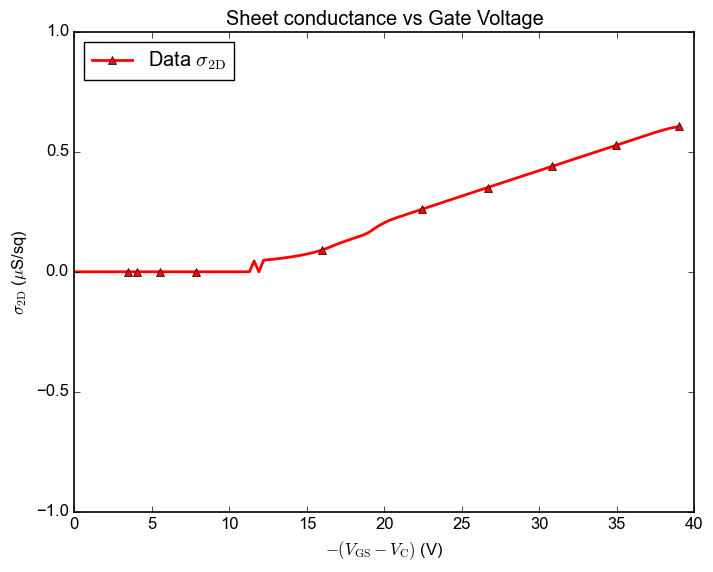

In [148]:
data = np.loadtxt("./Data-Mobility/20262304005_smooth_fake.dat")

V_GS = data[:, 0]
I_DS = data[:, 2]
V_DS = data[:, 3]
V_C = 0.5*(data[:, 4] + data[:, 5])
V_12 = data[:, 6]
sigma = data[:, 7]
plt.plot(-(V_GS - V_C), sigma*1e6, lw=2, label=r'Data $\sigma_\text{2D}$', color='red', marker='^', linestyle='-', markevery=40)




plt.xlabel(r"$-(V_\text{GS} - V_\text{C})$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ ($\mu$S/sq)")
plt.xlim(0, 40)
plt.ylim(-1.0, 1.0)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()

a = -1.69e-08 ± 1.57e-10
b = -9.04e-08 ± 3.33e-09
R^2 = 0.967
V_T = (-5.36 ± 0.204) V
mu = (2.92 ± 0.0272) cm^2/Vs


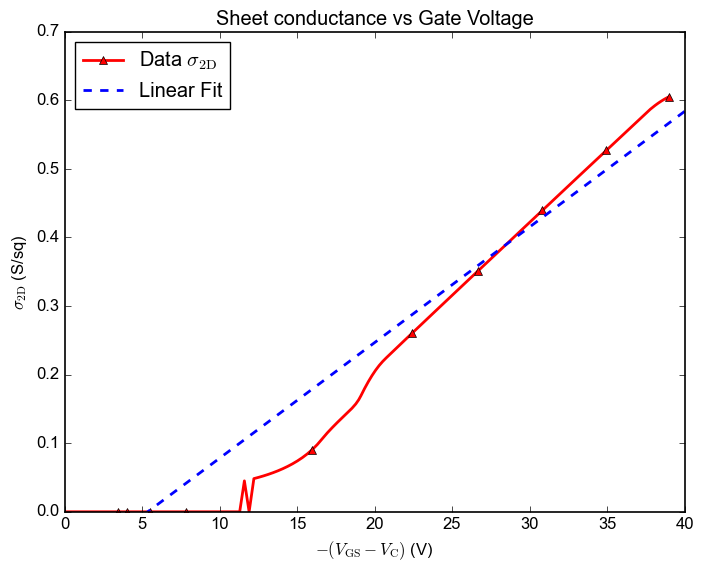

In [149]:
C =	2.6e-9	# F
A = 45e-6	# m^2
Ci = C/A # F/m^2
V_del = V_GS - V_C

def func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(func, V_del, sigma)
sigma_fit = func(V_del, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((sigma - sigma_fit) ** 2)
ss_tot = np.sum((sigma - np.mean(sigma)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr
V_T_fit = -b/a
V_T_err = abs(V_T_fit) * np.sqrt((b_err / b) ** 2 + (a_err / a) ** 2)
mu_fit = -a/Ci*1e4
mu_err = abs(mu_fit * a_err / a)

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"R^2 = {r2:.3f}")

print(f"V_T = ({V_T_fit:.3g} ± {V_T_err:.3g}) V")
print(f"mu = ({-a/Ci*1e4:.3g} ± {mu_err:.3g}) cm^2/Vs")

x = np.linspace(-40, 40, 100)
plt.plot(-(V_GS - V_C), sigma*1e6, lw=2, label=r'Data $\sigma_\text{2D}$', color='red', marker='^', linestyle='-', markevery=40)
plt.plot(-x, func(x, *popt)*1e6, lw=2, label='Linear Fit', color='blue', linestyle='--')
plt.xlabel(r"$-(V_\text{GS} - V_\text{C})$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ (S/sq)")
plt.xlim(0, 40)
plt.ylim(0, 0.7)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()

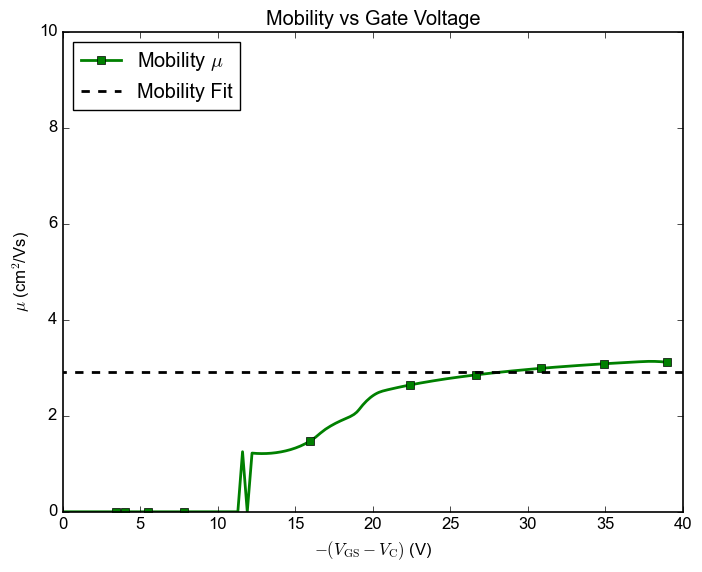

In [150]:
mu = -sigma / (Ci * (V_GS - V_T_fit - V_C)) * 1e4  # Convert to cm^2/Vs


plt.plot(-(V_GS - V_C), mu, lw=2, label=r'Mobility $\mu$', color='green', marker='s', linestyle='-', markevery=40)
plt.plot(-x, np.ones_like(x)*mu_fit, lw=2, label='Mobility Fit', color='black', linestyle='--')
plt.xlabel(r"$-(V_\text{GS} - V_\text{C})$ (V)")
plt.ylabel(r"$\mu$ (cm$^2$/Vs)")
plt.xlim(0, 40)
plt.ylim(0, 10)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Mobility vs Gate Voltage")
plt.show()